# Case study E5: differentiable MPC in a learning loop

DiffMPC (Toyota Research Institute, 2025) benchmarks differentiable MPC libraries on the inner loop of
policy learning (its Table 3): a batch of initial states runs a 50-step episode in which every step
solves an MPC problem and applies the first control, and the "backward" pass is the gradient of the
batch's episode cost with respect to the MPC's state weights. The contenders on CPU are mpc.pytorch,
DiffMPC itself and trajax (Theseus ships Linux wheels only).

Scaly writes the episode as one Function: a `scan` over the 50 steps, a `vmap` over the batch, and in
it an LQ MPC solved by a Riccati `scan`, whose reverse derivative is attached as the implicit rule of
the LQ problem (`sc.custom_derivative`). This notebook builds it, checks it, times it, and shows three
things the comparison turned up about the benchmark itself.

The Scaly cells run without any baseline environment. The baselines need `baseline/setup.sh` and are
off by default (`RUN_BASELINES`); their recorded results are in `results/`. The write-up is
`internal/notes/case_study_e5_report.html`.

In [1]:
import json
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

HERE = Path.cwd()
sys.path[:0] = [str(HERE), str(HERE.parent)]

import plotstyle
import scaly as sc
from scaly.codegen import render_c_module

import scaly_impl as si

plotstyle.use()
RUN_BASELINES = False  # True reruns baseline/run_baselines.py (about an hour) and compare.py; needs baseline/setup.sh
RESULTS = HERE / "results"

## The benchmark's problem

`scaly_impl.problem_data` draws the benchmark's data with the same generator calls as its
`utils.generate_problem_data`: `A = I + 0.1 N(0,1)` with its eigenvalues pulled inside radius 0.99,
`B` standard normal, `b = 0.01 N(0,1)`, initial states `5 N(0,1)`. The MPC has `T` knots with
$\tfrac12 \sum_t x_t^\top Q x_t + \tfrac12 \sum_t u_t^\top R u_t$, `Q = diag(qd)`, `R = I`, no
constraints: an LQ problem.

In [2]:
for k, p in si.PROBLEMS.items():
  print(f"Problem {k}: nx={p.nx}, nu={p.nu}, T={p.horizon} knots, batch {p.batch}, {p.steps} steps")
p = si.PROBLEMS[1]
d = si.problem_data(p.nx, p.nu, p.batch, 0)
print("largest |eigenvalue| of A:", np.abs(np.linalg.eigvals(d["A"])).max())

Problem 1: nx=8, nu=4, T=40 knots, batch 64, 50 steps
Problem 2: nx=8, nu=4, T=30 knots, batch 16, 50 steps
Problem 3: nx=8, nu=4, T=30 knots, batch 64, 50 steps
Problem 4: nx=8, nu=4, T=30 knots, batch 256, 50 steps
Problem 5: nx=16, nu=8, T=30 knots, batch 16, 50 steps
Problem 6: nx=16, nu=8, T=30 knots, batch 64, 50 steps
largest |eigenvalue| of A: 0.9917331640331025


## The MPC in Scaly

`mpc_function` is a Riccati `scan` backward over the horizon (`Q_uu` factored by the generated
Cholesky), returning $u_0 = K_0 x_0 + k_0$. Checked against the LQ problem's KKT system solved densely:

In [3]:
def kkt_u0(x0, qd, A, B, b, R, T):
  nx, nu, N = len(x0), R.shape[0], T - 1
  nz = T * nx + N * nu
  H = np.zeros((nz, nz))
  for t in range(T):
    H[t * nx : (t + 1) * nx, t * nx : (t + 1) * nx] = np.diag(qd)
  for t in range(N):
    o = T * nx + t * nu
    H[o : o + nu, o : o + nu] = R
  E, e = np.zeros((T * nx, nz)), np.zeros(T * nx)
  E[:nx, :nx], e[:nx] = np.eye(nx), x0
  for t in range(N):
    r = (t + 1) * nx
    E[r : r + nx, (t + 1) * nx : (t + 2) * nx] = -np.eye(nx)
    E[r : r + nx, t * nx : (t + 1) * nx] = A
    E[r : r + nx, T * nx + t * nu : T * nx + (t + 1) * nu] = B
    e[r : r + nx] = -b
  sol = np.linalg.solve(np.block([[H, E.T], [E, np.zeros((T * nx, T * nx))]]), np.concatenate([np.zeros(nz), e]))
  return sol[T * nx : T * nx + nu]


mpc = si.mpc_function(p.nx, p.nu, p.horizon)
x0 = d["x0"][0]
u_scaly = np.asarray(mpc(x0, np.ones(p.nx), d["A"].reshape(-1), d["B"].reshape(-1), d["b"], d["R"].reshape(-1)))
print("u0:", u_scaly, " difference from the KKT solution:", np.abs(u_scaly - kkt_u0(x0, np.ones(p.nx), d["A"], d["B"], d["b"], d["R"], p.horizon)).max())

u0: [ 4.05994886 -1.58599385 -4.19683328 -0.6154192 ]  difference from the KKT solution: 1.9539925233402755e-14


## The implicit rule

Differentiating through the Riccati recursion works (reverse mode through the `scan`) but carries a
reverse sweep over every step of it. The implicit-function theorem on the LQ problem's KKT system
(Amos et al., 2018) gives the whole reverse derivative from one more rollout: for a cotangent $\bar u$
of $u_0$, the adjoint LQ problem has the same Riccati gains and a single linear term at the first
stage, so $du_0 = -Q_{uu,0}^{-1}\bar u$, $du_t = K_t\, dx_t$, $dx_{t+1} = A\,dx_t + B\,du_t$, and every
cotangent is a sum over the horizon of products of the solution, its multipliers $P_t x_t + p_t$ and the
adjoint (`scaly_impl.implicit_rule`). Checked against AD through the recursion, for every input:

In [4]:
nx, nu, T = 4, 2, 7
rng = np.random.default_rng(0)
A = np.eye(nx) + 0.2 * rng.standard_normal((nx, nx))
B, b = rng.standard_normal((nx, nu)), 0.1 * rng.standard_normal(nx)
M = rng.standard_normal((nu, nu))
args = (rng.standard_normal(nx), 1 + rng.random(nx), A.reshape(-1), B.reshape(-1), b, (M @ M.T + np.eye(nu)).reshape(-1))
w = rng.standard_normal(nu)
names = ["x0", "qd", "A", "B", "b", "R"]
results = {}
for rule in (None, "implicit"):
  f = si.mpc_function(nx, nu, T, rule)

  @sc.function(sc.L("x0", nx), sc.L("qd", nx), sc.L("A", nx * nx), sc.L("B", nx * nu), sc.L("b", nx), sc.L("R", nu * nu), output=sc.G(*names), name=f"rule_check_{rule}")
  def grads(x0, qd, A, B, b, R):
    loss = (sc.const(w) * f(x0, qd, A, B, b, R)).sum()  # noqa: B023
    return tuple(sc.gradient(loss, v) for v in (x0, qd, A, B, b, R))

  results[rule] = [np.asarray(a) for a in grads(*args)]
for n, ad, rule in zip(names, results[None], results["implicit"]):
  print(f"{n:3s}: rule against AD {np.abs(ad - rule).max():.1e}")

x0 : rule against AD 0.0e+00
qd : rule against AD 1.5e-16
A  : rule against AD 7.5e-16
B  : rule against AD 3.3e-16
b  : rule against AD 6.7e-16
R  : rule against AD 2.8e-17


## The episode, and what Scaly does with it

`episode_function(problem, hoist)` `vmap`s the MPC over the batch inside a `scan` over the 50 steps.
Written as the benchmark writes it (`hoist=True`: the problem data broadcast to every MPC), the Riccati
recursion depends on nothing that changes, and Scaly's `scan` hoists that loop-invariant part: the
generated C computes it once, before the episode.

In [5]:
module = render_c_module(si.episode_function(p, True, "implicit"))
entry = module.body[module.body.rindex("int episode_1_implicit(") :]
print("\n".join(line for line in entry.splitlines() if "_raw(" in line or line.strip().startswith("for (long long k")))

  episode_step_1_implicit_hoist_1_raw(s1, s3, s4, s5, NULL);
  for (long long k_t3 = 0; k_t3 < 50; ++k_t3) {
    episode_step_1_implicit_hoisted_1_raw((s2 + (v0 * 513)), s1, s3, s4, s5, (s2 + ((1 - v0) * 513)), NULL);


That is a compiler doing its job on the program it was given, but it makes the forward pass one Riccati
recursion and 3200 affine feedbacks, which says nothing about solving MPC problems. With `hoist=False`
each batch element carries its own copy of the weights through the episode, as it would if they
changed between steps, so every step of every element solves its own MPC, which is the work the
baselines do. That is the variant compared below. Timed here on Problem 1:

In [6]:
def median_time(f, args, n=5):
  f(*args)
  samples = []
  for _ in range(n):
    t = time.perf_counter()
    f(*args)
    samples.append(time.perf_counter() - t)
  return 1e3 * float(np.median(samples))


a1 = si.arguments(d)
for hoist, rule in ((False, "implicit"), (False, None), (True, "implicit")):
  ep = si.episode_function(p, hoist, rule)
  gr = si.gradient_function(p, ep)
  label = f"{'hoisted' if hoist else 'per solve'}, {'implicit rule' if rule else 'AD through Riccati'}"
  print(f"{label:34s} forward {median_time(ep, a1):8.2f} ms   gradient {median_time(gr, a1):7.1f} ms")

per solve, implicit rule           forward    39.00 ms   gradient   161.5 ms


per solve, AD through Riccati      forward    37.93 ms   gradient   228.3 ms


hoisted, implicit rule             forward     0.14 ms   gradient    84.7 ms


## Whose gradient?

mpc.pytorch returns the gradient of the episode cost: its backward includes $\partial u_0 / \partial x_0$,
the path by which a change of `Q` moves later states and so later controls. DiffMPC's and trajax's
rules return no cotangent for the initial state, so their "gradient" drops that path. For this loss
that is not a small correction. Scaly's rule computes either (`rule="implicit_no_x0"` zeroes the state's
cotangent); both against central differences of a NumPy rollout (a symmetrized Riccati recursion: an
unsymmetrized one drifts by 1e-7 over 39 steps of these nearly unstable `A`, enough to spoil finite
differences):

In [7]:
def np_gains(qd, d, T):
  A, B, b, R = d["A"], d["B"], d["b"], d["R"]
  Q = np.diag(qd)
  P, pv = Q.copy(), np.zeros(len(qd))
  for _ in range(T - 1):
    pb = P @ b + pv
    quu, qux = R + B.T @ P @ B, B.T @ P @ A
    K, k = -np.linalg.solve(quu, qux), -np.linalg.solve(quu, B.T @ pb)
    P, pv = Q + A.T @ P @ A + qux.T @ K, A.T @ pb + qux.T @ k
    P = 0.5 * (P + P.T)
  return K, k


def np_episode(qd, d, p):
  K, k = np_gains(qd, d, p.horizon)
  X, cost = d["x0"], 0.0
  for _ in range(p.steps):
    U = X @ K.T + k
    X = X @ d["A"].T + U @ d["B"].T + d["b"]
    cost += np.sum(X**2) + np.sum(U**2)
  return cost


qd = np.ones(p.nx)
fd = np.array([(np_episode(qd + 1e-5 * e, d, p) - np_episode(qd - 1e-5 * e, d, p)) / 2e-5 for e in np.eye(p.nx)])
full = np.asarray(si.gradient_function(p, si.episode_function(p, False, "implicit"))(*a1))
trunc = np.asarray(si.gradient_function(p, si.episode_function(p, False, "implicit_no_x0"))(*a1))
print("finite differences   ", np.round(fd, 4))
print("Scaly, full          ", np.round(full, 4))
print("Scaly, truncated     ", np.round(trunc, 4))

finite differences    [-0.7965 -0.0991  0.1039 -0.5811  0.2673 -0.0874  0.0906  1.1083]
Scaly, full           [-0.7965 -0.0991  0.1039 -0.5811  0.2673 -0.0874  0.0906  1.1083]
Scaly, truncated      [ -12.4959   75.6468 -117.8789    9.4919    6.3223  -67.3402   72.969
   31.5451]


The truncated gradient is a hundred times larger and points elsewhere. The full one is small because
`Q = I` is already nearly optimal: with `R = I` the MPC's objective is the episode's own cost, and 40
knots are close to an infinite horizon. The recorded learning curves start from `Q = 3 I` instead and
follow each gradient with the same normalized step:

/var/folders/mc/38r0ggmx49l2jwwk6k9nc63h0000gn/T/ipykernel_21112/1359786564.py:14: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


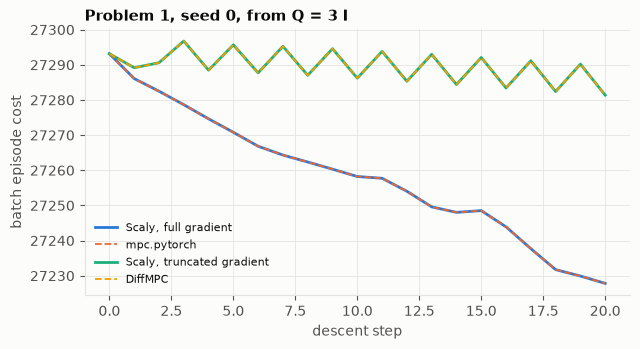

In [8]:
if RUN_BASELINES:
  subprocess.run([sys.executable, str(HERE / "baseline" / "run_baselines.py"), "--out", str(RESULTS / "baselines.json")], check=True)
  subprocess.run([sys.executable, str(HERE / "compare.py"), "--out", str(RESULTS / "scaly.json")], check=True)
curves = json.loads((RESULTS / "learning_curves.json").read_text())
fig, ax = plt.subplots(figsize=(6.5, 3.6))
style = {"scaly_full": ("C0", "-", "Scaly, full gradient"), "mpcpytorch": ("C1", "--", "mpc.pytorch"), "scaly_truncated": ("C2", "-", "Scaly, truncated gradient"), "diffmpc": ("C3", "--", "DiffMPC")}
for key, (color, ls, label) in style.items():
  if key in curves:
    ax.plot(curves[key]["loss"], color=color, ls=ls, lw=2 if ls == "-" else 1.3, label=label)
ax.set_xlabel("descent step")
ax.set_ylabel("batch episode cost")
ax.set_title("Problem 1, seed 0, from Q = 3 I")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

## The grid

`compare.py` runs `run_scaly.py` per problem in a fresh process; `baseline/run_baselines.py` runs each
baseline's own script. Every library is pinned to one thread (Scaly's C is single-threaded). Times are
the median over five seeds of one call each, after a warm-up, as the scripts measure them.

/var/folders/mc/38r0ggmx49l2jwwk6k9nc63h0000gn/T/ipykernel_21112/2953816464.py:18: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0.06, 1, 1))


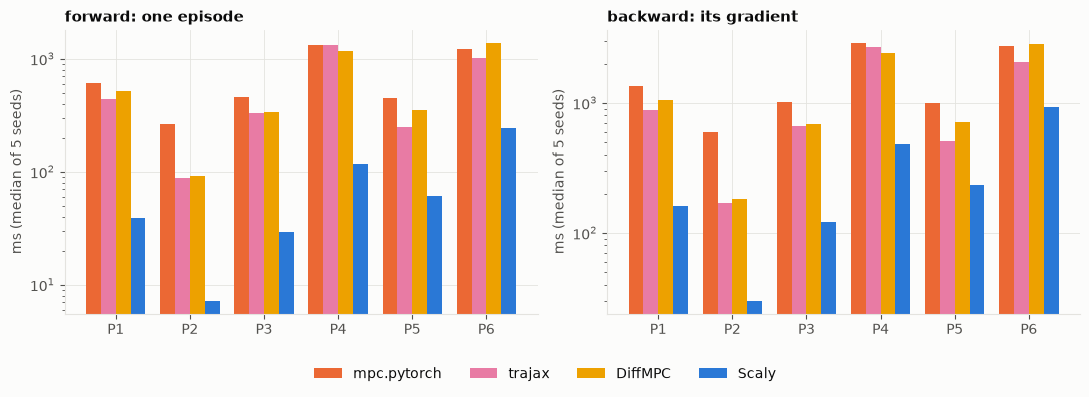

In [9]:
scaly_rows = json.loads((RESULTS / "scaly.json").read_text())["rows"]
base_rows = [r for r in json.loads((RESULTS / "baselines.json").read_text())["rows"] if r["threads"] == "1"]
impls = [("mpcpytorch", "mpc.pytorch", "C1"), ("trajax", "trajax", "C4"), ("diffmpc", "DiffMPC", "C3"), ("per_solve_implicit", "Scaly", "C0")]
problems = sorted({r["problem"] for r in scaly_rows})
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=False)
for ax, key, title in [(axes[0], "forward_s", "forward: one episode"), (axes[1], "backward_s", "backward: its gradient")]:
  for i, (impl, label, color) in enumerate(impls):
    vals = []
    for prob in problems:
      rows = [r for r in (scaly_rows if impl.startswith("per_") else base_rows) if r["problem"] == prob and r.get("variant", r.get("implementation")) == impl]
      vals.append(1e3 * np.median(rows[0][key]) if rows else np.nan)
    ax.bar(np.arange(len(problems)) + (i - 1.5) * 0.2, vals, 0.2, color=color, label=label)
  ax.set_yscale("log")
  ax.set_xticks(np.arange(len(problems)), [f"P{k}" for k in problems])
  ax.set_ylabel("ms (median of 5 seeds)")
  ax.set_title(title)
fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.05))
fig.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

In [10]:
print(f"{'problem':>7s} {'implementation':28s} {'forward ms':>11s} {'gradient ms':>12s}")
for prob in problems:
  for r in [x for x in base_rows if x["problem"] == prob]:
    print(f"{prob:7d} {r['implementation']:28s} {1e3 * np.median(r['forward_s']):11.1f} {1e3 * np.median(r['backward_s']):12.1f}")
  for r in [x for x in scaly_rows if x["problem"] == prob]:
    print(f"{prob:7d} {'Scaly ' + r['variant']:28s} {1e3 * np.median(r['forward_s']):11.2f} {1e3 * np.median(r['backward_s']):12.1f}")

problem implementation                forward ms  gradient ms
      1 mpcpytorch                         612.3       1340.8
      1 diffmpc                            518.4       1055.7
      1 trajax                             444.0        883.7
      1 Scaly per_solve_implicit           38.66        161.4
      1 Scaly per_solve_ad                 38.27        227.0
      1 Scaly hoisted_implicit              0.19         84.5
      2 mpcpytorch                         266.8        598.0
      2 diffmpc                             91.0        180.9
      2 trajax                              87.1        170.2
      2 Scaly per_solve_implicit            7.22         30.1
      2 Scaly per_solve_ad                  7.25         42.4
      2 Scaly hoisted_implicit              0.06         15.8
      3 mpcpytorch                         461.2       1018.5
      3 diffmpc                            338.3        681.4
      3 trajax                             328.6        664.9
      3 

## Findings

- **Scaly is 9.9 to 12.1x faster forward and 5.0 to 5.6x faster on the gradient at 8 states**
  (Problems 1 to 4) than the fastest baseline, each on one thread: the plan's 5x criterion. There
  the baselines' time is mostly per-call dispatch, which one generated C function removes.
- **At 16 states (Problems 5, 6) the lead shrinks to 4x and 2.1x.** The arithmetic now dominates, and
  XLA runs each operation across the batch at once while Scaly's `vmap` goes element by element
  (CS-9 in `internal/todo.md`).
- **The implicit rule is exact and 1.3 to 1.4x faster than AD through the recursion**, through the
  existing `sc.custom_derivative`. The gradient still costs about 4x the forward pass: the rule's call
  recomputes the MPC's output, and the rule recomputes the Riccati recursion (CS-10).
- **The baselines do not compute the same gradient.** mpc.pytorch's is the episode cost's gradient
  (Scaly's to 1e-12). DiffMPC's and trajax's drop the MPC's dependence on its initial state; Scaly
  reproduces trajax's to 1e-12 and DiffMPC's to its own accuracy of 2e-5, and that gradient is 50 to
  200x the true one and gains less than a fifth as much.
- **Written as the benchmark writes it, the MPC is hoisted out of the episode by Scaly's `scan`**, and
  the forward pass takes 0.06 to 0.53 ms. The comparison above uses the per-solve variant instead;
  hoisting does not yet reach into the rule's reverse pass (CS-14).